Ch25
# 可视化正定性
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

a
用 def 自定义函数 visualize()，这个函数有三个输入。
b
用 matplotlib.pyplot.figure()，简作 plt.figure()，创建了一个图形对象 fig。参
数 figsize=(6,3)代表图宽 6 英寸，图高 3 英寸。
c
用 fig.add_subplot() 在图形对象 fig 中添加一个子图，输出轴对象为 ax_3D。
参数 (1, 2, 1) 表示将图形划分为 1 行 2 列的子图布局，并选择第 1 个子图。参数第一个
数字 1 表示行数，第二个数字 2 表示列数，第三个数字 1 表示选择的子图位置。
projection='3d' 表示使用 3D 投影坐标系，用于呈现三维可视化方案。
d
在三维轴对象 ax_3D 中用 plot_wireframe()绘制网格图。
xx1 和 xx2 是网格数据，用于表示 x 和 y 坐标的网格点。
f2_array 包含了与网格点对应的二元函数坐标的数值。
rstride 和 cstride 分别表示行和列的步幅，控制网格之间的间隔，这里设置为 10。

view_init(azim=0, elev=0)从正侧面平视，几乎看不到立体感

view_init(azim=45, elev=30)从右前上方观察，立体感适中（Matplotlib 默认值）

view_init(azim=-120, elev=30)从左后上方观察，数据分布更清晰

view_init(azim=0, elev=90)俯视图，类似 2D 平面图


In [2]:
# 导入包
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, lambdify, expand, simplify

# 定义可视化函数
def visualize(xx1,xx2,f2_array):

    fig = plt.figure(figsize=(6,3))
    # 左子图，三维
    ax_3D = fig.add_subplot(1, 2, 1, projection='3d')

    ax_3D.plot_wireframe(xx1, xx2, f2_array,
                         rstride=10, cstride=10,
                         color = [0.8,0.8,0.8],
                         linewidth = 0.25)

    ax_3D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')
    # 等高线
    ax_3D.set_xlabel('$x_1$'); ax_3D.set_ylabel('$x_2$') # 标签
    ax_3D.set_zlabel('$f(x_1,x_2)$')
    ax_3D.set_proj_type('ortho') # 正交投影
    ax_3D.set_xticks([]); ax_3D.set_yticks([])
    ax_3D.set_zticks([])  #不显示轴
    ax_3D.view_init(azim=-120, elev=30) #观察视角
    ax_3D.grid(False) # 不显示网格
    ax_3D.set_xlim(xx1.min(), xx1.max());  # 范围
    ax_3D.set_ylim(xx2.min(), xx2.max())
    '''
  azim = -120°：相机绕 Z 轴逆时针旋转了 120°（负号表示逆时针方向）。默认 azim=0 是从 X 轴正方向（即右侧）观察。
  elev = 30°：相机从水平面（XY 平面）抬高了 30°，形成一定俯视效果。
  这种视角组合通常能获得一个立体感较强且不容易遮挡数据的观察角度，常用于 3D 散点图、曲面图等。
    '''
    # 右子图，平面等高线
    ax_2D = fig.add_subplot(1, 2, 2)
    ax_2D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')

    ax_2D.set_xlabel('$x_1$'); ax_2D.set_ylabel('$x_2$')
    ax_2D.set_xticks([]); ax_2D.set_yticks([])
    ax_2D.set_aspect('equal'); ax_2D.grid(False)
    ax_2D.set_xlim(xx1.min(), xx1.max());
    ax_2D.set_ylim(xx2.min(), xx2.max())
    plt.tight_layout()

a
利用 numpy.meshgrid() 生成网格化数据，代表横纵轴坐标点。
b
自定义函数，用来更方便地生成表 4中不同 f(x) = x
T @ A2×2 @ x。
c
定义符号变量 x1 和 x2，分别代表 x1和 x2。
d
相当于构造了符号列向量
1
2
x
x
 
=    
x 。
e
计算 x
T @ A2×2 @ x，虽然只有一个元素，但是结果为二维数组。
f
从上述结果中提取符号表达式。
g
打印 x
T @ A2×2 @ x 解析式。
h
用 math.lambdify() 将符号解析式转化为 Python 函数。
i
计算给定网格坐标下的二元函数 f(x) = x
T @ A2×2 @ x 值，结果也是二维数组。
j
举了一个例子。
k
调用自定义函数 fcn()计算函数值。
l
调用自定义函数 visualize() 可视化二元函数。
请大家在 JupyterLab 中练习计算并可视化表 4所有示例

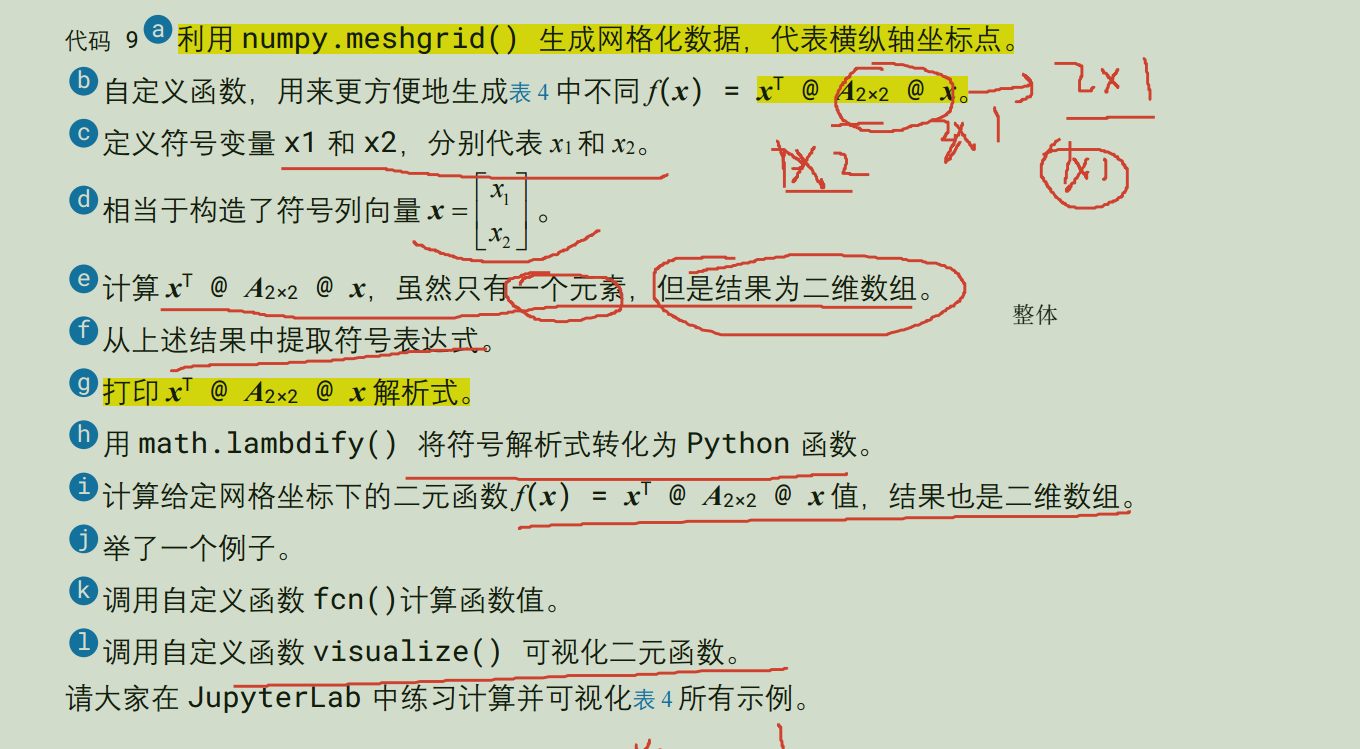

2*x1*x2


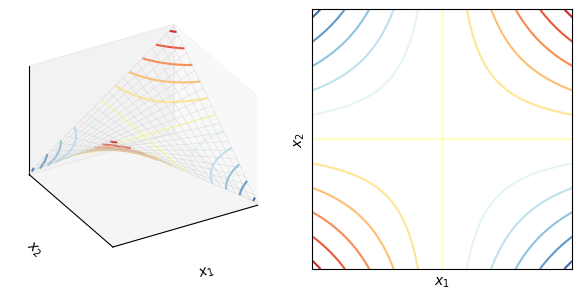

In [3]:
# 生成数据
x1_array = np.linspace(-2,2,201)
x2_array = np.linspace(-2,2,201)

xx1, xx2 = np.meshgrid(x1_array, x2_array) #生成网格
'''
x.T * A * x 计算出来是一个 1×1 的矩阵（标量），而不是纯数字。
[0, 0] 就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式，这样才能被 plot3d 正确解析。
'''
# 定义二元函数 A:矩阵 xx1,xx2:数据

def fcn(A, xx1, xx2):

    x1,x2 = symbols('x1 x2')
    x = np.array([[x1,x2]]).T #行向量
    f_x = x.T@A@x
    f_x = f_x[0][0] # [0, 0]就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式。
    print(simplify(expand(f_x)))
    #计算 xT @ A2×2 @ x，虽然只有一个元素，但是结果为二维数组。
    #从上述结果中提取符号表达式。
    #打印 xT @ A2×2 @ x 解析式。
    f_x_fcn = lambdify([x1,x2],f_x) # 将表达式转为函数
    ff_x = f_x_fcn(xx1,xx2)  # 计算

    return ff_x

# 不定矩阵
A = np.array([[0, 1],
              [1, 0]])

f2_array = fcn(A, xx1, xx2) #z轴数据
visualize(xx1,xx2,f2_array)  # 2*X1*X2

In [4]:
# 定义可视化函数
def visualize2(xx1,xx2,f2_array):

    fig = plt.figure(figsize=(6,3))
    # 左子图，三维
    ax_3D = fig.add_subplot(1, 2, 1, projection='3d')

    ax_3D.plot_wireframe(xx1, xx2, f2_array,
                         rstride=10, cstride=10,
                         color = [0.8,0.8,0.8],
                         linewidth = 0.25)

    ax_3D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')
    # 等高线
    ax_3D.set_xlabel('$x_1$'); ax_3D.set_ylabel('$x_2$') # 标签
    ax_3D.set_zlabel('$f(x_1,x_2)$')
    ax_3D.set_proj_type('ortho') # 正交投影
    ax_3D.set_xticks([]); ax_3D.set_yticks([])
    ax_3D.set_zticks([])  #不显示轴

    ax_3D.view_init(azim=0, elev=0) #观察视角

    ax_3D.grid(False) # 不显示网格
    ax_3D.set_xlim(xx1.min(), xx1.max());  # 范围
    ax_3D.set_ylim(xx2.min(), xx2.max())
    '''
  azim = -120°：相机绕 Z 轴逆时针旋转了 120°（负号表示逆时针方向）。默认 azim=0 是从 X 轴正方向（即右侧）观察。
  elev = 30°：相机从水平面（XY 平面）抬高了 30°，形成一定俯视效果。
  这种视角组合通常能获得一个立体感较强且不容易遮挡数据的观察角度，常用于 3D 散点图、曲面图等。
    '''
    # 右子图，平面等高线
    ax_2D = fig.add_subplot(1, 2, 2)
    ax_2D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')

    ax_2D.set_xlabel('$x_1$'); ax_2D.set_ylabel('$x_2$')
    ax_2D.set_xticks([]); ax_2D.set_yticks([])
    ax_2D.set_aspect('equal'); ax_2D.grid(False)
    ax_2D.set_xlim(xx1.min(), xx1.max());
    ax_2D.set_ylim(xx2.min(), xx2.max())
    plt.tight_layout()

[[x1**2 + x2**2]]
<class 'numpy.ndarray'>
----------------
x1**2 + x2**2
<class 'sympy.core.add.Add'>
x1**2 + x2**2


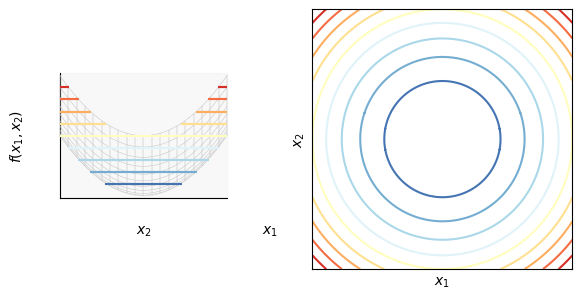

In [5]:
# 生成数据
x1_array = np.linspace(-2,2,201)
x2_array = np.linspace(-2,2,201)

xx1, xx2 = np.meshgrid(x1_array, x2_array) #生成网格
'''
x.T * A * x 计算出来是一个 1×1 的矩阵（标量），而不是纯数字。
[0, 0] 就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式，这样才能被 plot3d 正确解析。
'''
# 定义二元函数 A:矩阵 xx1,xx2:数据

def fcn2(A, xx1, xx2):

    x1,x2 = symbols('x1 x2')
    x = np.array([[x1,x2]]).T #行向量
    f_x = x.T@A@x
    print(f_x)
    print(type(f_x))
    print('----------------')
    f_x = f_x[0][0] # [0, 0]就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式。
    print(f_x)
    print(type(f_x))
    print(simplify(expand(f_x)))
    #计算 xT @ A2×2 @ x，虽然只有一个元素，但是结果为二维数组。
    #从上述结果中提取符号表达式。
    #打印 xT @ A2×2 @ x 解析式。
    f_x_fcn = lambdify([x1,x2],f_x) # 将表达式转为函数
    ff_x = f_x_fcn(xx1,xx2)  # 计算

    return ff_x

# 不定矩阵
A = np.array([[1,0],
              [0,1]])

f2_array = fcn2(A, xx1, xx2) #z轴数据
visualize2(xx1,xx2,f2_array)  # x1^2 + x2^2

ax_3D.view_init(azim=0, elev=0) #观察视角

azim = -120°：相机绕 Z 轴逆时针旋转了 120°（负号表示逆时针方向）。默认 azim=0 是从 X 轴正方向（即右侧）观察。

elev = 30°：相机从水平面（XY 平面）抬高了 30°，形成一定俯视效果。
这种视角组合通常能获得一个立体感较强且不容易遮挡数据的观察角度，常用于 3D 散点图、曲面图等。

view_init(azim=0, elev=0)从正侧面平视，几乎看不到立体感

view_init(azim=45, elev=30)从右前上方观察，立体感适中（Matplotlib 默认值）

view_init(azim=-120, elev=30)从左后上方观察，数据分布更清晰

view_init(azim=0, elev=90)俯视图，类似 2D 平面图

[[x1**2 + x2**2]]
<class 'numpy.ndarray'>
----------------
x1**2 + x2**2
<class 'sympy.core.add.Add'>
x1**2 + x2**2


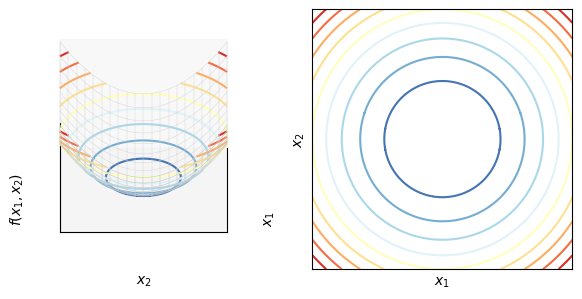

In [6]:
# 定义可视化函数
def visualize2(xx1,xx2,f2_array):

    fig = plt.figure(figsize=(6,3))
    # 左子图，三维
    ax_3D = fig.add_subplot(1, 2, 1, projection='3d')

    ax_3D.plot_wireframe(xx1, xx2, f2_array,
                         rstride=10, cstride=10,
                         color = [0.8,0.8,0.8],
                         linewidth = 0.25)

    ax_3D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')
    # 等高线
    ax_3D.set_xlabel('$x_1$'); ax_3D.set_ylabel('$x_2$') # 标签
    ax_3D.set_zlabel('$f(x_1,x_2)$')
    ax_3D.set_proj_type('ortho') # 正交投影
    ax_3D.set_xticks([]); ax_3D.set_yticks([])
    ax_3D.set_zticks([])  #不显示轴

    ax_3D.view_init(azim=0, elev=30) #观察视角

    ax_3D.grid(False) # 不显示网格
    ax_3D.set_xlim(xx1.min(), xx1.max());  # 范围
    ax_3D.set_ylim(xx2.min(), xx2.max())
    '''
  azim = -120°：相机绕 Z 轴逆时针旋转了 120°（负号表示逆时针方向）。默认 azim=0 是从 X 轴正方向（即右侧）观察。
  elev = 30°：相机从水平面（XY 平面）抬高了 30°，形成一定俯视效果。
  这种视角组合通常能获得一个立体感较强且不容易遮挡数据的观察角度，常用于 3D 散点图、曲面图等。
    '''
    # 右子图，平面等高线
    ax_2D = fig.add_subplot(1, 2, 2)
    ax_2D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')

    ax_2D.set_xlabel('$x_1$'); ax_2D.set_ylabel('$x_2$')
    ax_2D.set_xticks([]); ax_2D.set_yticks([])
    ax_2D.set_aspect('equal'); ax_2D.grid(False)
    ax_2D.set_xlim(xx1.min(), xx1.max());
    ax_2D.set_ylim(xx2.min(), xx2.max())
    plt.tight_layout()
# 生成数据
x1_array = np.linspace(-2,2,201)
x2_array = np.linspace(-2,2,201)

xx1, xx2 = np.meshgrid(x1_array, x2_array) #生成网格
'''
x.T * A * x 计算出来是一个 1×1 的矩阵（标量），而不是纯数字。
[0, 0] 就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式，这样才能被 plot3d 正确解析。
'''
# 定义二元函数 A:矩阵 xx1,xx2:数据

def fcn2(A, xx1, xx2):

    x1,x2 = symbols('x1 x2')
    x = np.array([[x1,x2]]).T #行向量
    f_x = x.T@A@x
    print(f_x)
    print(type(f_x))
    print('----------------')
    f_x = f_x[0][0] # [0, 0]就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式。
    print(f_x)
    print(type(f_x))
    print(simplify(expand(f_x)))
    #计算 xT @ A2×2 @ x，虽然只有一个元素，但是结果为二维数组。
    #从上述结果中提取符号表达式。
    #打印 xT @ A2×2 @ x 解析式。
    f_x_fcn = lambdify([x1,x2],f_x) # 将表达式转为函数
    ff_x = f_x_fcn(xx1,xx2)  # 计算

    return ff_x

# 不定矩阵
A = np.array([[1,0],
              [0,1]])

f2_array = fcn2(A, xx1, xx2) #z轴数据
visualize2(xx1,xx2,f2_array)  # x1^2 + x2^2

[[x1**2 + x2**2]]
<class 'numpy.ndarray'>
----------------
x1**2 + x2**2
<class 'sympy.core.add.Add'>
x1**2 + x2**2


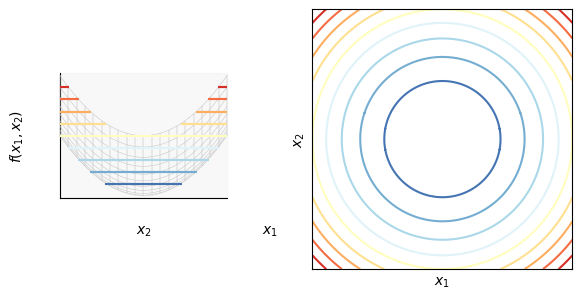

In [7]:
# 定义可视化函数
def visualize2(xx1,xx2,f2_array,a,b):

    fig = plt.figure(figsize=(6,3))
    # 左子图，三维
    ax_3D = fig.add_subplot(1, 2, 1, projection='3d')

    ax_3D.plot_wireframe(xx1, xx2, f2_array,
                         rstride=10, cstride=10,
                         color = [0.8,0.8,0.8],
                         linewidth = 0.25)

    ax_3D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')
    # 等高线
    ax_3D.set_xlabel('$x_1$'); ax_3D.set_ylabel('$x_2$') # 标签
    ax_3D.set_zlabel('$f(x_1,x_2)$')
    ax_3D.set_proj_type('ortho') # 正交投影
    ax_3D.set_xticks([]); ax_3D.set_yticks([])
    ax_3D.set_zticks([])  #不显示轴

    ax_3D.view_init(azim=a, elev=b) #观察视角

    ax_3D.grid(False) # 不显示网格
    ax_3D.set_xlim(xx1.min(), xx1.max());  # 范围
    ax_3D.set_ylim(xx2.min(), xx2.max())
    '''
  azim = -120°：相机绕 Z 轴逆时针旋转了 120°（负号表示逆时针方向）。默认 azim=0 是从 X 轴正方向（即右侧）观察。
  elev = 30°：相机从水平面（XY 平面）抬高了 30°，形成一定俯视效果。
  这种视角组合通常能获得一个立体感较强且不容易遮挡数据的观察角度，常用于 3D 散点图、曲面图等。
    '''
    # 右子图，平面等高线
    ax_2D = fig.add_subplot(1, 2, 2)
    ax_2D.contour(xx1, xx2, f2_array,
                  levels = 12, cmap = 'RdYlBu_r')

    ax_2D.set_xlabel('$x_1$'); ax_2D.set_ylabel('$x_2$')
    ax_2D.set_xticks([]); ax_2D.set_yticks([])
    ax_2D.set_aspect('equal'); ax_2D.grid(False)
    ax_2D.set_xlim(xx1.min(), xx1.max());
    ax_2D.set_ylim(xx2.min(), xx2.max())
    plt.tight_layout()
# 生成数据
x1_array = np.linspace(-2,2,201)
x2_array = np.linspace(-2,2,201)

xx1, xx2 = np.meshgrid(x1_array, x2_array) #生成网格
'''
x.T * A * x 计算出来是一个 1×1 的矩阵（标量），而不是纯数字。
[0, 0] 就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式，这样才能被 plot3d 正确解析。
'''
# 定义二元函数 A:矩阵 xx1,xx2:数据

def fcn2(A, xx1, xx2):

    x1,x2 = symbols('x1 x2')
    x = np.array([[x1,x2]]).T #行向量
    f_x = x.T@A@x
    print(f_x)
    print(type(f_x))
    print('----------------')
    f_x = f_x[0][0] # [0, 0]就是取出这个矩阵中的唯一元素（第 0 行第 0 列），得到一个普通的标量表达式。
    print(f_x)
    print(type(f_x))
    print(simplify(expand(f_x)))
    #计算 xT @ A2×2 @ x，虽然只有一个元素，但是结果为二维数组。
    #从上述结果中提取符号表达式。
    #打印 xT @ A2×2 @ x 解析式。
    f_x_fcn = lambdify([x1,x2],f_x) # 将表达式转为函数
    ff_x = f_x_fcn(xx1,xx2)  # 计算

    return ff_x

# 不定矩阵
A = np.array([[1,0],
              [0,1]])

f2_array = fcn2(A, xx1, xx2) #z轴数据
visualize2(xx1,xx2,f2_array, 0, 0)  # x1^2 + x2^2

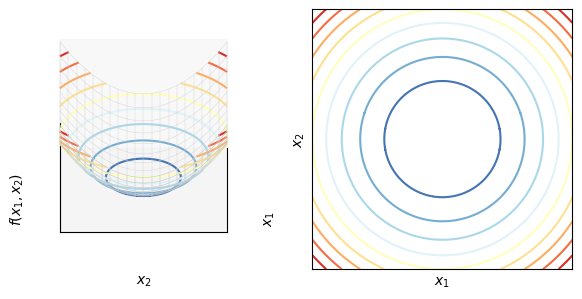

In [8]:
visualize2(xx1,xx2,f2_array, 0, 30)

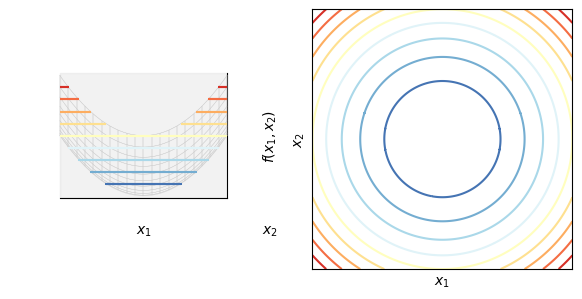

In [9]:
visualize2(xx1,xx2,f2_array, 90, 0)

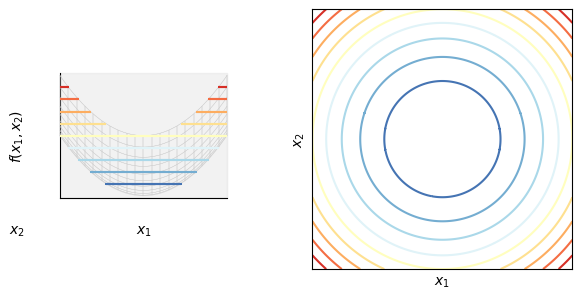

In [13]:
visualize2(xx1,xx2,f2_array, -90, 0)

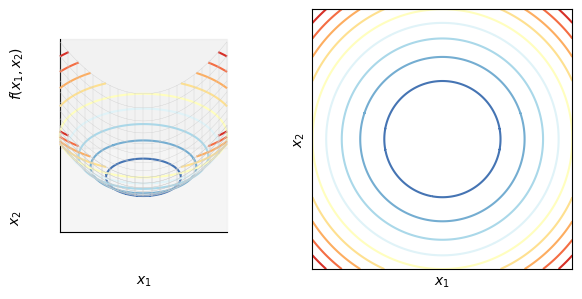

In [11]:
visualize2(xx1,xx2,f2_array, 90, 30)

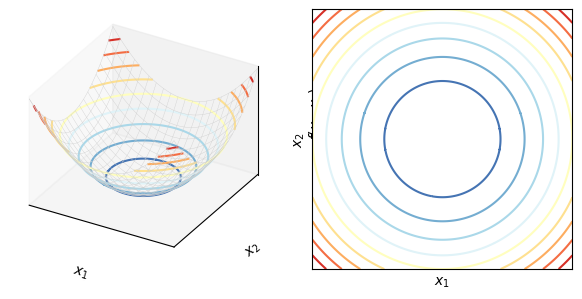

In [12]:
visualize2(xx1,xx2,f2_array, 120, 30)

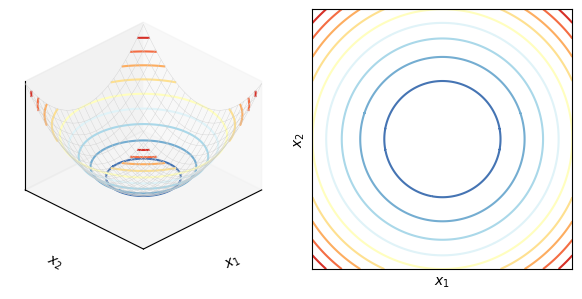

In [14]:
visualize2(xx1,xx2,f2_array, 45, 30)

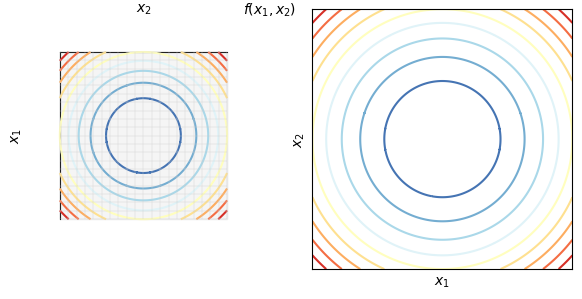

In [15]:
visualize2(xx1,xx2,f2_array, 0, 90)

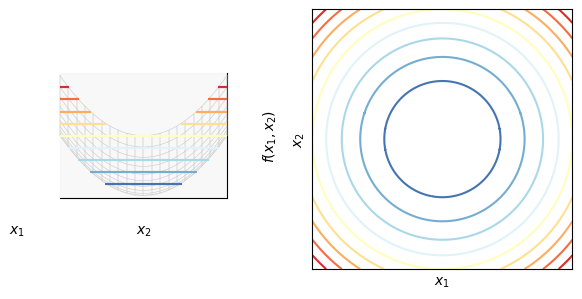

In [16]:
visualize2(xx1,xx2,f2_array, 180, 0)

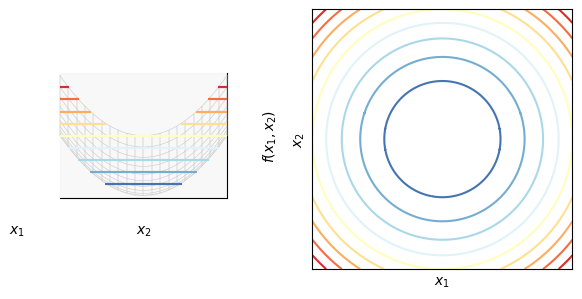

In [17]:
visualize2(xx1,xx2,f2_array, -180, 0)

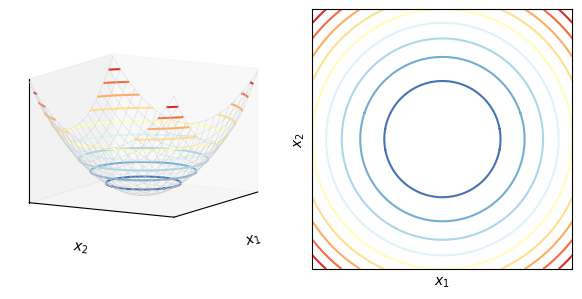

In [18]:
visualize2(xx1,xx2,f2_array, 30, 10)

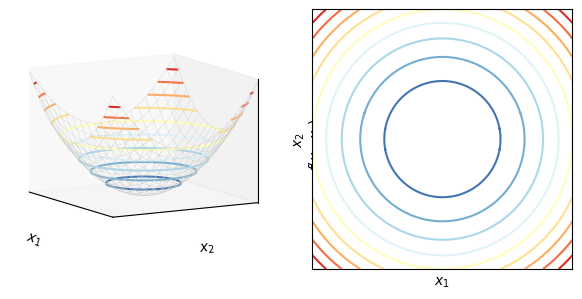

In [19]:
visualize2(xx1,xx2,f2_array, -30, 10)

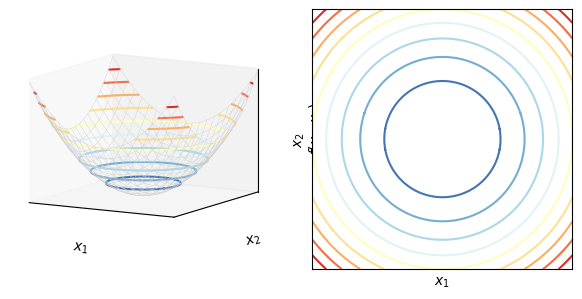

In [20]:
visualize2(xx1,xx2,f2_array, -60, 10)